参考文档：https://librosa.org/doc/

```bash
pip install librosa
```

In [1]:
# !pip install librosa

In [2]:
%matplotlib inline
import librosa

from IPython import display
from matplotlib import pyplot as plt

### 1. load加载音频文件
常用参数：
- `path`: 加载音频文件的路径
- `sr`: 采样率
- `mono`: 默认是`True`单声道，非单声道就填写几条声道
- `offset`: 偏移多少秒，截取片段的时候会用到
- `duration`: 默认是`None`获取全部音频数据，想获取多少秒可填写
- `dtype`: 默认是`numpy.float32`,数据会归一化处理，乘以32767就是真实值
- `res_type`: 可以重采样，默认不会动

In [3]:
! ls ../../../data/audio/test/001.wav

../../../data/audio/test/001.wav


In [4]:
filepath = "../../../data/audio/test/001.wav"

In [5]:
# display.Audio(filepath)

#### 1.1 读取音频文件

In [6]:
# 文件读取
data, sampling_rate = librosa.load(filepath, sr=None, mono=True)
data.shape, sampling_rate

((39411,), 4800)

#### 1.2 获取指定时长

In [7]:
# 只获取2秒看下
data2, sampling_rate2 = librosa.load(filepath, duration=2, sr=None, mono=True)
data2.shape, sampling_rate2

((9600,), 4800)

**可以看到音频采样率是4800，那么我们取2秒，那么就是9600条数据。**

#### 1.3 设置采样率

In [8]:
# 设置采样率为16k
data3, sampling_rate3 = librosa.load(filepath, offset=5.0, duration=2, sr=16000, mono=True)
data3.shape, sampling_rate3

((32000,), 16000)

### 2. 显示波形
重点参数：
- `y`: `np.ndarray`波形数据
- `sr`: 采样率默认22050
- `max_points`: 最多只显示多少个点，默认11025
- `axis`: 横坐标，默认是`time`
- `offset`: 默认0.0，起始位置
- `ax`: matplotlib的Axes对象，用于绘制波形图的轴

#### 2.1 librosa.display.waveshow 

In [9]:
data.shape, sampling_rate

((39411,), 4800)

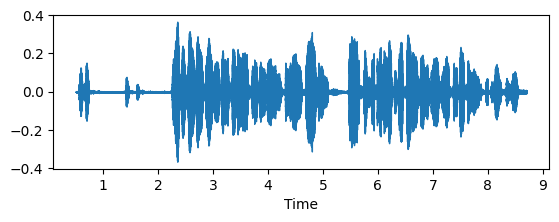

In [10]:
plt.figure().set_figheight(2)
librosa.display.waveshow(data, sr=sampling_rate, offset=0.5)
plt.show()

#### 2.2 使用matplotlib画音频波形

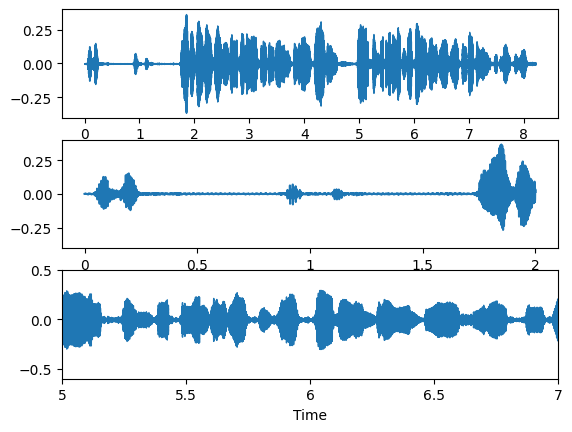

In [11]:
fig = plt.figure(1)

ax1 = fig.add_subplot(3, 1, 1)  # 创建一个3行1列的子图
librosa.display.waveshow(data, sr=sampling_rate, ax=ax1)

ax2 = fig.add_subplot(3, 1, 2)
librosa.display.waveshow(data2, sr=sampling_rate2, ax=ax2)

ax3 = fig.add_subplot(3, 1, 3)
ax3.set(xlim=[5.0, 7.0], ylim=[-0.6, 0.5])
librosa.display.waveshow(data3, sr=sampling_rate3, offset=5.0, ax=ax3, marker="")

plt.show()

In [12]:
# librosa.display.waveshow??

### 3. 保存音频

In [13]:
import soundfile as sf

In [14]:
sf.write("../../../data/audio/test/001-test.wav", data, sampling_rate)

In [15]:
!ls ../../../data/audio/test

001-test.wav 001.wav      002.wav
